In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import cv2
import os

In [22]:
def load_images_from_folder(folder_path):
    images = []
    for filename in sorted(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(img)
    return images

In [23]:
def prepare_data_for_roc(gt_images, algo_images, binarization_threshold = 127):
    gt_array = np.array(gt_images)
    algo_array = np.array(algo_images)
    
    gt_flat = gt_array.flatten()
    algo_flat = algo_array.flatten()
    
    y_true = (gt_flat > binarization_threshold).astype(int) 
    
    y_scores = algo_flat / 255.0
    
    return y_true, y_scores

In [24]:
def calculate_roc_manual(y_true, y_scores):
    thresholds = np.unique(y_scores)[::-1]
    thresholds = np.insert(thresholds, 0, thresholds[0] + 0.1)
    tpr_list = []
    fpr_list = []
    
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)
    
    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        
        FP = np.sum((y_pred == 1) & (y_true == 0))
        
        TPR = TP / P if P > 0 else 0
        FPR = FP / N if N > 0 else 0
        
        tpr_list.append(TPR)
        fpr_list.append(FPR)
        
    return np.array(fpr_list), np.array(tpr_list), thresholds

In [25]:
def calculate_auc_manual(fpr, tpr):
    auc = 0
    for i in range(1, len(fpr)):
        width = fpr[i] - fpr[i-1]
        avg_height = (tpr[i] + tpr[i-1]) / 2.0
        auc += width * avg_height
        
    return auc

In [26]:
def calculate_jaccard_dice_manual(y_true, y_scores, best_thresh):
    y_pred = (y_scores >= best_thresh).astype(int)
    
    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    
    jaccard = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0.0
    dice = (2 * TP) / ((2 * TP) + FP + FN) if ((2 * TP) + FP + FN) > 0 else 0.0
    
    return jaccard, dice

In [27]:
def plot_and_compare_roc(y_true, y_scores, algo_name):
    fpr_manual, tpr_manual, thresholds = calculate_roc_manual(y_true, y_scores)
    auc_manual = calculate_auc_manual(fpr_manual, tpr_manual)
    
    optimal_idx = np.argmax(tpr_manual - fpr_manual)
    best_thresh = thresholds[optimal_idx]
    
    jaccard, dice = calculate_jaccard_dice_manual(y_true, y_scores, best_thresh)
    
    fpr_sklearn, tpr_sklearn, _ = roc_curve(y_true, y_scores)
    auc_sklearn = auc(fpr_sklearn, tpr_sklearn)
    
    print(f"--- Algorithm {algo_name} Results ---")
    print(f"Manual AUC: {auc_manual:.4f}")
    print(f"Sklearn AUC: {auc_sklearn:.4f}")
    print(f"Best Threshold (Youden): {best_thresh:.4f}")
    print(f"Jaccard Index: {jaccard:.4f}")
    print(f"Dice Coefficient: {dice:.4f}\n")
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_manual, tpr_manual, color='blue', lw=5, alpha=0.5, 
             label=f'Manual ROC (AUC = {auc_manual:.4f})')
    plt.plot(fpr_sklearn, tpr_sklearn, color='red', lw=2, linestyle='--', 
             label=f'Sklearn ROC (AUC = {auc_sklearn:.4f})')
    
    plt.plot(fpr_manual[optimal_idx], tpr_manual[optimal_idx], marker='o', color='green', markersize=8, label='Best Threshold')
    
    plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Random Guess')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve - {algo_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

In [28]:
def obtain_roc_curve_and_auc(gt_path, algo_path, algo_name):    
    gt_images = load_images_from_folder(gt_path)
    algo_images = load_images_from_folder(algo_path)
        
    y_true, y_scores = prepare_data_for_roc(gt_images, algo_images, 127)
    
    plot_and_compare_roc(y_true, y_scores, algo_name)

In [29]:
GT_DIR = os.path.join("images", "ground_truth")
ALGO_DIR = os.path.join("images", "algorithms")

--- Algorithm alg1 Results ---
Manual AUC: 0.7906
Sklearn AUC: 0.7906
Best Threshold (Youden): 0.0039
Jaccard Index: 0.1324
Dice Coefficient: 0.2338



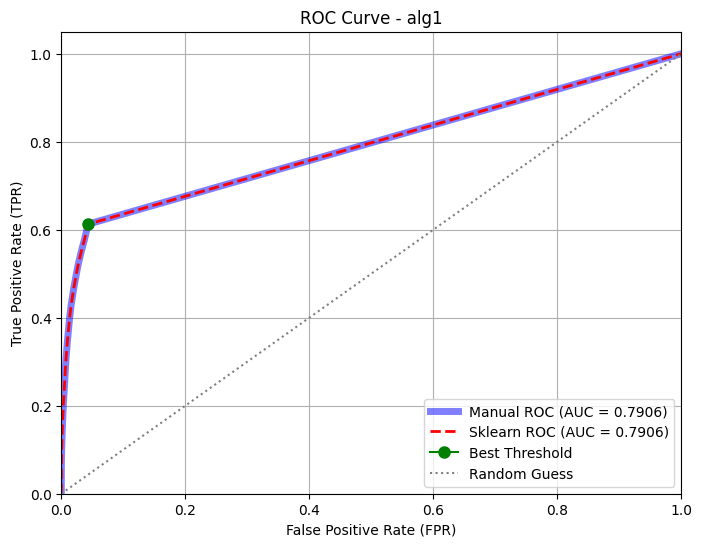

--- Algorithm alg2 Results ---
Manual AUC: 0.8772
Sklearn AUC: 0.8772
Best Threshold (Youden): 0.3216
Jaccard Index: 0.0357
Dice Coefficient: 0.0689



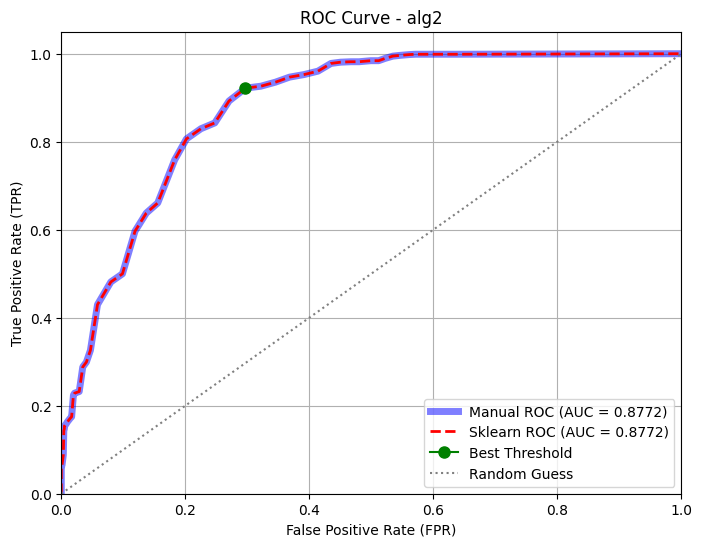

--- Algorithm alg3 Results ---
Manual AUC: 0.8812
Sklearn AUC: 0.8812
Best Threshold (Youden): 0.0196
Jaccard Index: 0.2687
Dice Coefficient: 0.4235



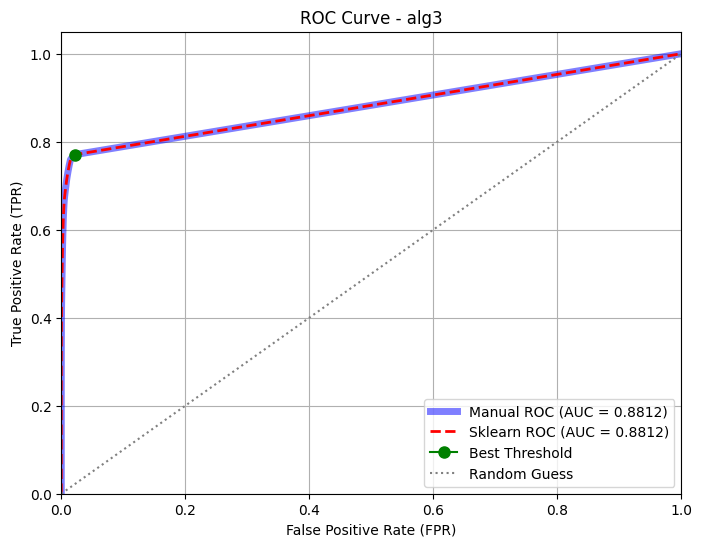

--- Algorithm alg4 Results ---
Manual AUC: 0.8619
Sklearn AUC: 0.8619
Best Threshold (Youden): 0.0039
Jaccard Index: 0.0877
Dice Coefficient: 0.1613



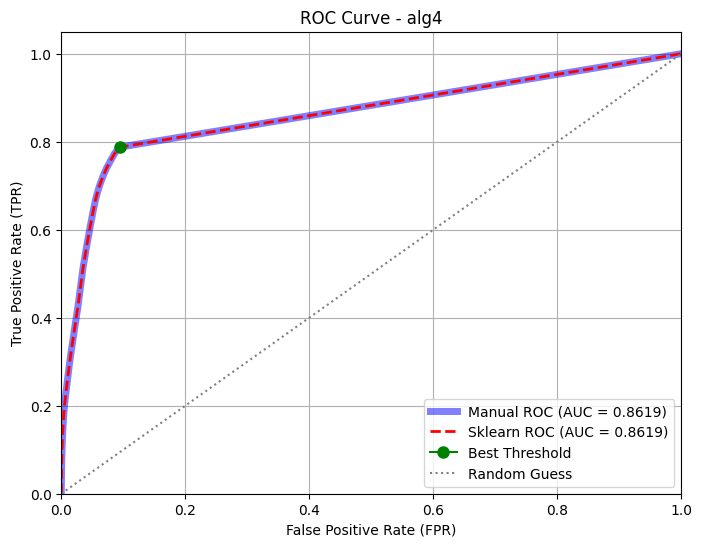

--- Algorithm alg5 Results ---
Manual AUC: 0.7405
Sklearn AUC: 0.7405
Best Threshold (Youden): 0.1804
Jaccard Index: 0.1920
Dice Coefficient: 0.3221



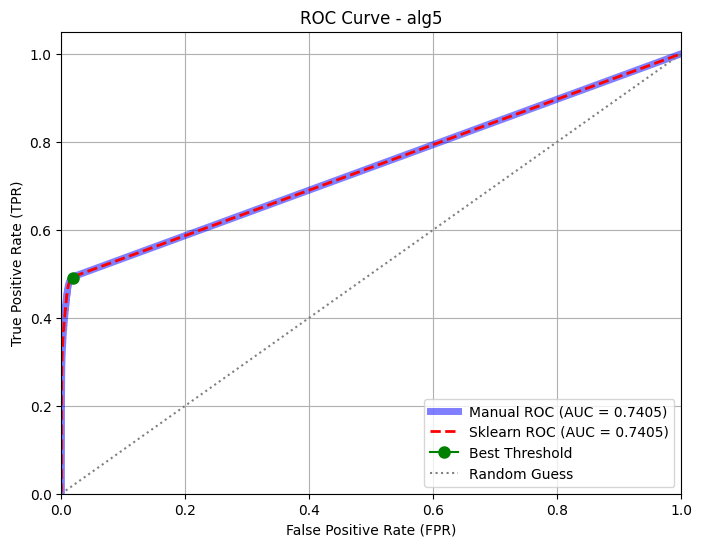

--- Algorithm alg6 Results ---
Manual AUC: 0.9044
Sklearn AUC: 0.9044
Best Threshold (Youden): 0.0196
Jaccard Index: 0.0625
Dice Coefficient: 0.1177



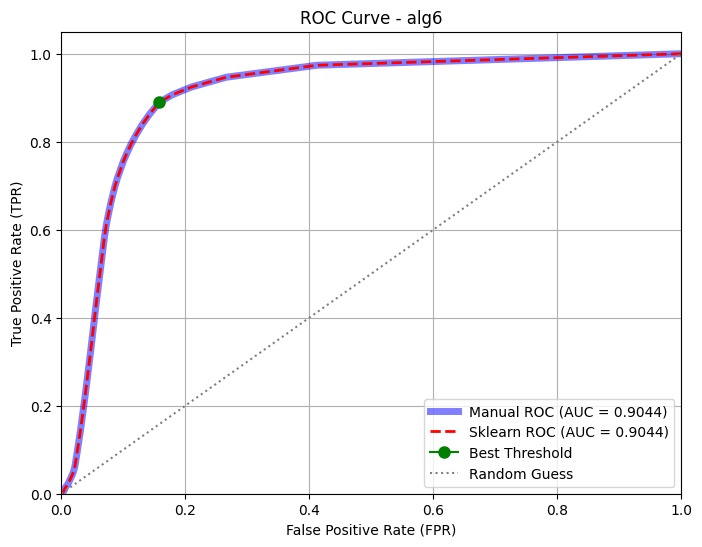

In [30]:
if os.path.exists(ALGO_DIR) and os.path.exists(GT_DIR):
    algorithms = [d for d in os.listdir(ALGO_DIR) if os.path.isdir(os.path.join(ALGO_DIR, d))]
    
    for algo_name in sorted(algorithms):
        algo_path = os.path.join(ALGO_DIR, algo_name)
        obtain_roc_curve_and_auc(GT_DIR, algo_path, algo_name)